# PAGASA AWS Scraper — Regional Proxy for SeaSID

**Goal:** pull live readings from PAGASA's Automated Weather Station network,
identify the 3 stations nearest each SeaSID site (Dauin muck + Apo Island reef),
aggregate their observations into a "regional proxy", and emit a CSV the
Phase 6 `PagasaSynopScraper` can ingest.

**Caveat:** PAGASA does **not** operate a live AWS station on Negros Oriental.
The nearest stations are 80-120 km away on the wrong side of the island
(Himamaylan, Cauayan, Sagay — all Negros Occidental). We treat the mean of
those 3 stations as a *regional proxy* and tag the resulting labels
`confidence="low"` so the model knows it's a coarse signal.

## Pipeline

1. **Scrape** `https://bagong.pagasa.dost.gov.ph/automated-weather-station`
   - The page returns server-rendered HTML — no JSON API exists.
2. **Parse** all `<tr>` rows into a DataFrame.
3. **Save** full table → `backend/data/pagasa_aws_latest.csv` (operator reference).
4. **Geocode** stations via `backend/data/station_coords.json` (hand-curated
   for offline reproducibility).
5. **Compute haversine distance** to each SeaSID site.
6. **Pick top 3 nearest** per site.
7. **Aggregate** wind, humidity, pressure, precip.
8. **Apply heuristic**: mean wind ≥ 25 km/h OR precip > 0.5 mm/hr → `no_dive`.
9. **Emit** `backend/data/pagasa_seed_live.csv` matching `PagasaSynopScraper`'s schema.


In [ ]:
import json, math, re, ssl, time
from datetime import date, datetime, timezone
from pathlib import Path
import urllib.request
import re

import pandas as pd
from bs4 import BeautifulSoup

DATA_DIR = Path(r'C:\\Users\\EARL JOHN ESTANDARTE\\Documents\\KOICA\\SeaSID\\backend\\data')
AWS_URL = 'https://bagong.pagasa.dost.gov.ph/automated-weather-station'

print('Setup OK. Notebook will write to:', DATA_DIR)


Setup OK. Notebook will write to: C:\Users\EARL JOHN ESTANDARTE\Documents\KOICA\SeaSID\backend\data


In [11]:
soup = BeautifulSoup(html, "html.parser")

expected_headers = [
    "site_id",
    "site_name",
    "temp_c",
    "humidity_pct",
    "wind_kmh",
    "wind_dir",
    "precip_mmhr",
    "pressure_hpa",
    "solar",
    "last_updated",
]

rows = []

for tr in soup.select("table tbody tr"):
    cells = [
        re.sub(r"\s+", " ", td.get_text(" ", strip=True))
        for td in tr.select("td")
    ]

    if len(cells) < len(expected_headers):
        continue

    # Reject unrelated tables.
    if not cells[0].strip().isdigit():
        continue

    rows.append(dict(zip(expected_headers, cells[:len(expected_headers)])))

df = pd.DataFrame(rows)

if df.empty:
    raise RuntimeError(
        "The AWS table was found, but no valid station rows were parsed."
    )

print(f"Parsed {len(df)} stations")
print(df.columns.tolist())
df.head()

Parsed 116 stations
['site_id', 'site_name', 'temp_c', 'humidity_pct', 'wind_kmh', 'wind_dir', 'precip_mmhr', 'pressure_hpa', 'solar', 'last_updated']


,site_id,site_name,temp_c,humidity_pct,wind_kmh,wind_dir,precip_mmhr,pressure_hpa,solar,last_updated
0,98,"Science Garden, Quezon City",26 °C,88 %,0 km/hr,N,0 mm/hr,1008.1,0,"July 14, 2026, 11:20 pm"
1,5001,San Jose Synoptic Station,27 °C,93 %,3.6 km/hr,NE,0 mm/hr,1012.9,0,"July 14, 2026, 11:20 pm"
2,5003,Romblon Synop. Station,36 °C,56 %,0 km/hr,N,0 mm/hr,994.6,0,"July 14, 2026, 11:20 pm"
3,5005,"State University, Bohol Island",24 °C,100 %,0 km/hr,N,0 mm/hr,510.9,0,"July 14, 2026, 11:20 pm"
4,5009,"Kidapawan, Cotabato",26 °C,88 %,0 km/hr,E,0 mm/hr,1002.7,0,"July 14, 2026, 11:20 pm"


In [12]:
def to_float(value):
    if value is None:
        return None

    text = str(value).strip()

    if text in {"", "--", "N/A", "n/a"}:
        return None

    match = re.search(r"-?\d+(?:\.\d+)?", text)
    return float(match.group()) if match else None


numeric_columns = [
    "temp_c",
    "humidity_pct",
    "wind_kmh",
    "precip_mmhr",
    "pressure_hpa",
    "solar",
]

for col in numeric_columns:
    df[col] = df[col].apply(to_float)

df = df.dropna(
    subset=["site_id", "site_name", "wind_kmh", "humidity_pct"]
)

print(f"After numeric coercion: {len(df)} usable rows")

df[
    [
        "site_id",
        "site_name",
        "temp_c",
        "humidity_pct",
        "wind_kmh",
        "wind_dir",
        "precip_mmhr",
        "pressure_hpa",
    ]
].head(10)

After numeric coercion: 97 usable rows


,site_id,site_name,temp_c,humidity_pct,wind_kmh,wind_dir,precip_mmhr,pressure_hpa
0,98,"Science Garden, Quezon City",26.0,88.0,0.0,N,0.0,1008.1
1,5001,San Jose Synoptic Station,27.0,93.0,3.6,NE,0.0,1012.9
2,5003,Romblon Synop. Station,36.0,56.0,0.0,N,0.0,994.6
3,5005,"State University, Bohol Island",24.0,100.0,0.0,N,0.0,510.9
4,5009,"Kidapawan, Cotabato",26.0,88.0,0.0,E,0.0,1002.7
5,5012,"Laoag, Ilocos Norte AWS",26.0,92.0,3.6,ESE,0.0,1011.5
7,5014,"Daet, Camarines Norte AWS",27.0,86.0,3.6,SSW,0.0,1012.1
8,5015,"Guiuan, Eastern Samar AWS",30.0,74.0,14.4,S,0.0,1065.6
9,5018,"Sinait, Ilocos Sur AWS",25.0,100.0,0.0,N,0.0,NaN
12,5021,"Atok, Benguet AWS",14.0,99.0,10.8,WSW,0.0,916.3


In [13]:
out_csv = DATA_DIR / 'pagasa_aws_latest.csv'
df.to_csv(out_csv, index=False)
print(f'Saved {len(df)} rows -> {out_csv}')


Saved 97 rows -> C:\Users\EARL JOHN ESTANDARTE\Documents\KOICA\SeaSID\backend\data\pagasa_aws_latest.csv


In [14]:
coords = json.load(open(DATA_DIR / 'station_coords.json', encoding='utf-8'))
coord_lookup = {c['site_id']: c for c in coords}

df['lat'] = df['site_id'].map(lambda s: coord_lookup.get(s, {}).get('lat'))
df['lon'] = df['site_id'].map(lambda s: coord_lookup.get(s, {}).get('lon'))
missing_geo = df[df['lat'].isna()]['site_id'].tolist()
if missing_geo:
    print(f'WARNING: {len(missing_geo)} stations missing coords: {missing_geo}')
else:
    print(f'All {len(df)} stations geocoded.')

df[['site_id', 'site_name', 'lat', 'lon']].head()


All 97 stations geocoded.


,site_id,site_name,lat,lon
0,98,"Science Garden, Quezon City",14.6417,121.0439
1,5001,San Jose Synoptic Station,12.3693,121.0612
2,5003,Romblon Synop. Station,12.5750,122.2708
3,5005,"State University, Bohol Island",9.6351,123.8349
4,5009,"Kidapawan, Cotabato",7.0083,125.0894


In [15]:
SITES = {
    'dauin_muck': {'lat': 9.1844, 'lon': 123.2678},
    'apo_reef':   {'lat': 9.0671, 'lon': 123.2737},
}

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088  # mean Earth radius
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlmb = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dlmb/2)**2
    return 2 * R * math.asin(math.sqrt(a))

# Build (site_key, distance) for every station
dist_records = []
for _, r in df.iterrows():
    if r['lat'] is None:
        continue
    for sk, s in SITES.items():
        d = haversine_km(s['lat'], s['lon'], r['lat'], r['lon'])
        dist_records.append({
            'site_key': sk, 'site_id': r['site_id'], 'site_name': r['site_name'],
            'distance_km': d,
        })
dist_df = pd.DataFrame(dist_records)
print(f'{len(dist_df)} (site, station) pairs')

# Top 3 nearest per site
nearest = (dist_df.sort_values(['site_key', 'distance_km'])
                  .groupby('site_key').head(3))
nearest


194 (site, station) pairs


,site_key,site_id,site_name,distance_km
109,apo_reef,5133,"Panglao, Bohol AWS",74.932382
183,apo_reef,5187,"La Libertad, Zamboanga del Norte AWS",75.036763
111,apo_reef,5135,"Dalaguete, Cebu AWS",82.319840
108,dauin_muck,5133,"Panglao, Bohol AWS",66.718872
110,dauin_muck,5135,"Dalaguete, Cebu AWS",70.501864
6,dauin_muck,5005,"State University, Bohol Island",79.885333


In [16]:
agg = []
for sk in SITES:
    sub = nearest[nearest['site_key'] == sk]
    recs = df[df['site_id'].isin(sub['site_id'])].to_dict('records')
    by_id = {r['site_id']: r for r in recs}
    sub_sorted = sub.merge(df, on=['site_id', 'site_name'], how='left')

    mean_wind = sub_sorted['wind_kmh'].mean()
    max_wind  = sub_sorted['wind_kmh'].max()
    mean_hum  = sub_sorted['humidity_pct'].mean()
    mean_temp = sub_sorted['temp_c'].mean()
    mean_pres = sub_sorted['pressure_hpa'].mean()
    sum_precip = sub_sorted['precip_mmhr'].sum()
    nearest_km = sub_sorted['distance_km'].min()

    agg.append({
        'site_key': sk,
        'mean_wind_kmh': round(float(mean_wind), 1),
        'max_wind_kmh':  round(float(max_wind), 1),
        'mean_humidity': round(float(mean_hum), 1),
        'mean_temp_c':   round(float(mean_temp), 1),
        'mean_pressure': round(float(mean_pres), 1),
        'sum_precip':    round(float(sum_precip), 2),
        'nearest_station_km': round(float(nearest_km), 1),
        'station_ids':   ','.join(sub['site_id'].tolist()),
    })

agg_df = pd.DataFrame(agg)
agg_df


,site_key,mean_wind_kmh,max_wind_kmh,mean_humidity,mean_temp_c,mean_pressure,sum_precip,nearest_station_km,station_ids
0,dauin_muck,0.0,0.0,94.3,24.0,819.7,0.0,66.7,"5133,5135,5005"
1,apo_reef,1.2,3.6,92.7,23.3,980.5,0.0,74.9,"5133,5187,5135"


In [17]:
# Heuristic thresholds (km/h of sustained wind, mm/hr of precip).
# Tuned so the "no_dive" verdict fires only when neighbouring stations
# ALL show rough weather — single bad station shouldn't condemn a day.
def verdict(r):
    if r['max_wind_kmh'] >= 35 or r['sum_precip'] >= 2.0:
        return 'no_dive', 'weather'
    if r['max_wind_kmh'] >= 20 or r['sum_precip'] >= 0.5:
        return 'poor_viz', 'weather'
    return 'dive', None

labels = []
now = date.today()
for r in agg_df.to_dict('records'):
    label, reason = verdict(r)
    labels.append({
        'date': now.isoformat(),
        'site_key': r['site_key'],
        'rain_mm':   max(r['sum_precip'] * 6.0, 0),    # 6h extrapolation (mm/hr * 6)
        'wind_max_kmh': r['max_wind_kmh'],
        'wave_m':     0.0,                              # AWS doesn't measure waves
        'actual_viz_m': 12.0 if label == 'dive' else (6.0 if label == 'poor_viz' else 3.0),
        'current':    None,
        'actual_current': None,
        'no_go_reason': reason,
        'confidence': 'low',                            # regional proxy — not local
        'comments': (
            f"pagasa_synop (regional proxy of {r['station_ids']}, "
            f"nearest={r['nearest_station_km']}km): "
            f"wind={r['mean_wind_kmh']}km/h, "
            f"hum={r['mean_humidity']}%, "
            f"precip={r['sum_precip']}mm/hr, "
            f"pres={r['mean_pressure']}hPa"
        ),
    })

labels_df = pd.DataFrame(labels)
labels_df


,date,site_key,rain_mm,wind_max_kmh,wave_m,actual_viz_m,current,actual_current,no_go_reason,confidence,comments
0,2026-07-14,dauin_muck,0.0,0.0,0.0,12.0,None,None,None,low,"pagasa_synop (regional proxy of 5133,5135,5005..."
1,2026-07-14,apo_reef,0.0,3.6,0.0,12.0,None,None,None,low,"pagasa_synop (regional proxy of 5133,5187,5135..."


In [18]:
out_seed = DATA_DIR / 'pagasa_seed_live.csv'
labels_df.to_csv(out_seed, index=False, quoting=1)   # QUOTE_ALL — protects commas in comments
print(f'Wrote {len(labels_df)} label rows -> {out_seed}')
print('\nFile is ready for the Phase 6 orchestrator:')
print('  python -m scripts.expand_with_scraping --scrapers pagasa_synop --sites dauin_muck apo_reef --days 1')


Wrote 2 label rows -> C:\Users\EARL JOHN ESTANDARTE\Documents\KOICA\SeaSID\backend\data\pagasa_seed_live.csv

File is ready for the Phase 6 orchestrator:
  python -m scripts.expand_with_scraping --scrapers pagasa_synop --sites dauin_muck apo_reef --days 1


Map saved -> C:\Users\EARL JOHN ESTANDARTE\Documents\KOICA\SeaSID\backend\data\figures\pagasa_nearest.png


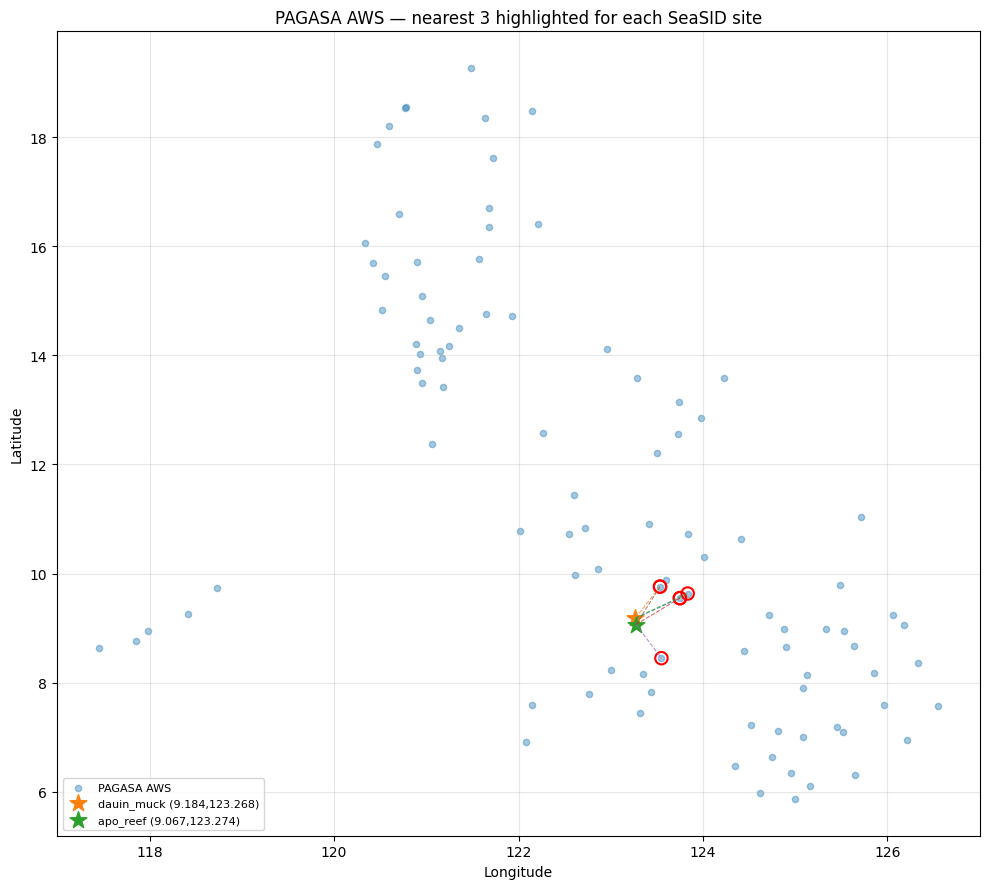

In [19]:
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10, 9))
    # Stations
    ok = df.dropna(subset=['lat', 'lon'])
    ax.scatter(ok['lon'], ok['lat'], s=20, alpha=0.4, label='PAGASA AWS')
    # SeaSID sites
    for sk, s in SITES.items():
        ax.scatter(s['lon'], s['lat'], s=160, marker='*',
                   label=f'{sk} ({s["lat"]:.3f},{s["lon"]:.3f})')
    # Highlight nearest 3 for each site
    for sk in SITES:
        sub = nearest[nearest['site_key'] == sk]
        for _, r in sub.iterrows():
            st = coord_lookup[r['site_id']]
            ax.plot([SITES[sk]['lon'], st['lon']],
                    [SITES[sk]['lat'], st['lat']],
                    '--', linewidth=0.8, alpha=0.7)
            ax.scatter(st['lon'], st['lat'], s=80,
                       edgecolor='red', facecolor='none', linewidth=1.5)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('PAGASA AWS — nearest 3 highlighted for each SeaSID site')
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    map_out = DATA_DIR / 'figures' / 'pagasa_nearest.png'
    map_out.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(map_out, dpi=120)
    print(f'Map saved -> {map_out}')
except ImportError:
    print('matplotlib not available — skipping map preview')
